# 06 — KWM Client Portfolio Hedging

**Phase 6 deliverable**

This connects the project directly to wealth management: a hypothetical diversified private
client portfolio, evaluated under real geopolitical shock scenarios, with four candidate hedge
strategies compared on cost, protection, and efficiency.

## Data used

- **Spot prices and volatility levels**: the most recent values from the real historical data
  pulled in Phase 5 (as of early July 2026), not assumed placeholders.
- **Scenario returns**: calibrated directly from the *actual* asset moves measured in Phase 5's
  event study (E1 = war start, E3 = ceasefire extension), not invented numbers. The one
  exception -- a "mild escalation" scenario -- is explicitly interpolated, since none of the
  three real events was a mild one; that's flagged clearly below.
- **Option pricing**: the Phase 1 Black-Scholes-Merton engine, restated here so this notebook is
  self-contained.

## A portfolio composition note

The plan's example portfolio includes QQQ, which isn't part of this project's asset set (no
QQQ history was pulled in Phase 2/5). Its weight is folded into SPY here instead, and that
substitution is called out explicitly rather than silently assumed.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import os

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

DATA_DIR = "data/cleaned_hist"
OUT_DIR = "data/hedging"
os.makedirs(OUT_DIR, exist_ok=True)

PORTFOLIO_VALUE = 1_000_000  # hypothetical client, $1M

TICKERS_NEEDED = ["SPY", "USO", "JETS", "XLY", "XLV", "GLD", "VIX", "OVX"]
latest = {}
for ticker in TICKERS_NEEDED:
    df = pd.read_csv(f"{DATA_DIR}/{ticker}.csv", parse_dates=["Date"]).sort_values("Date")
    latest[ticker] = {"date": df["Date"].iloc[-1], "price": df["Adj Close"].iloc[-1]}

for t, v in latest.items():
    print(f"{t:5s}: {v['price']:.2f}  (as of {v['date'].date()})")


SPY  : 744.78  (as of 2026-07-02)
USO  : 103.98  (as of 2026-07-02)
JETS : 33.20  (as of 2026-07-02)
XLY  : 117.12  (as of 2026-07-02)
XLV  : 163.74  (as of 2026-07-02)
GLD  : 378.13  (as of 2026-07-02)
VIX  : 15.81  (as of 2026-07-03)
OVX  : 41.62  (as of 2026-07-02)


## 2. The hypothetical client portfolio

$1,000,000 hypothetical diversified private-client portfolio. QQQ's allocation from the
original plan is folded into SPY, since QQQ data wasn't part of this project's pipeline.


In [2]:
PORTFOLIO_WEIGHTS = {
    "SPY": 0.65,   # broad equity + growth (QQQ folded in)
    "XLY": 0.10,   # consumer discretionary
    "JETS": 0.05,  # travel / airline exposure
    "XLV": 0.10,   # defensive healthcare
    "cash_bonds": 0.10,  # interest-rate sensitive, assumed flat in these scenarios
}
assert abs(sum(PORTFOLIO_WEIGHTS.values()) - 1.0) < 1e-9

portfolio_table = pd.DataFrame([
    {"holding": k, "weight": v, "dollar_value": round(v * PORTFOLIO_VALUE)}
    for k, v in PORTFOLIO_WEIGHTS.items()
])
portfolio_table


,holding,weight,dollar_value
0,SPY,0.65,650000
1,XLY,0.10,100000
2,JETS,0.05,50000
3,XLV,0.10,100000
4,cash_bonds,0.10,100000


## 3. Scenarios, calibrated from Phase 5's real event data

- **Scenario B -- Major Disruption**: the *actual* measured asset returns from E1 (the war's
  start, Feb 28 - Mar 2, 2026). This is real, not assumed.
- **Scenario C -- De-escalation**: the *actual* measured asset returns from E3 (the ceasefire
  extension, Jun 15, 2026). Also real.
- **Scenario A -- Mild Escalation**: no real event in this project's sample was a *mild* one --
  E1 was a full war outbreak. This scenario is therefore constructed as 35% of Scenario B's
  magnitude, same direction. It is a modeling assumption, not a measurement, and is labeled as
  such throughout.


In [3]:
EVENT_METRICS_PATH = "data/event_study/event_metrics.csv"
event_metrics = pd.read_csv(EVENT_METRICS_PATH)

def scenario_from_event(event_id):
    sub = event_metrics[event_metrics["event_id"] == event_id].set_index("ticker")
    return sub["price_move_pct"].to_dict()

scenario_B_major_disruption = scenario_from_event("E1")   # real
scenario_C_deescalation = scenario_from_event("E3")        # real

MILD_SCALE = 0.35
scenario_A_mild_escalation = {
    ticker: round(move * MILD_SCALE, 2) for ticker, move in scenario_B_major_disruption.items()
}

scenarios = {
    "A_mild_escalation": scenario_A_mild_escalation,
    "B_major_disruption": scenario_B_major_disruption,
    "C_deescalation": scenario_C_deescalation,
}

scenario_table = pd.DataFrame(scenarios).T
scenario_table.index.name = "scenario"
scenario_table["source"] = ["Interpolated: 35% of Scenario B (no real mild-escalation event in sample)",
                             "Real: E1 (war start, Feb 28 - Mar 2, 2026)",
                             "Real: E3 (ceasefire extension, Jun 15, 2026)"]
scenario_table


,USO,JETS,SPY,XLE,XLY,XLV,GLD,source
scenario,,,,,,,,
A_mild_escalation,10.14,-3.36,-0.21,0.74,-0.12,-0.94,-0.64,Interpolated: 35% of Scenario B (no real mild-...
B_major_disruption,28.96,-9.61,-0.60,2.12,-0.35,-2.70,-1.82,"Real: E1 (war start, Feb 28 - Mar 2, 2026)"
C_deescalation,-17.68,12.56,-0.51,-5.96,-1.22,0.13,-5.02,"Real: E3 (ceasefire extension, Jun 15, 2026)"


## 4. Black-Scholes engine (from Phase 1)

In [4]:
def d1_d2(S, K, T, r, sigma, q=0.0):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_price(S, K, T, r, sigma, q, right):
    d1, d2 = d1_d2(S, K, T, r, sigma, q)
    if right == "call":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

def bs_greeks(S, K, T, r, sigma, q, right):
    d1, d2 = d1_d2(S, K, T, r, sigma, q)
    pdf_d1 = norm.pdf(d1)
    disc_q, disc_r = np.exp(-q * T), np.exp(-r * T)
    gamma = disc_q * pdf_d1 / (S * sigma * np.sqrt(T))
    vega = S * disc_q * pdf_d1 * np.sqrt(T) / 100
    if right == "call":
        delta = disc_q * norm.cdf(d1)
        theta = (-S*disc_q*pdf_d1*sigma/(2*np.sqrt(T)) - r*K*disc_r*norm.cdf(d2) + q*S*disc_q*norm.cdf(d1)) / 365
        rho = K * T * disc_r * norm.cdf(d2) / 100
    else:
        delta = disc_q * (norm.cdf(d1) - 1)
        theta = (-S*disc_q*pdf_d1*sigma/(2*np.sqrt(T)) + r*K*disc_r*norm.cdf(-d2) - q*S*disc_q*norm.cdf(-d1)) / 365
        rho = -K * T * disc_r * norm.cdf(-d2) / 100
    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta, "rho": rho}


## 5. Hedge instrument setup

A 30-calendar-day hedge horizon (~monthly), priced using the most recent spot and vol-proxy
levels from Phase 5's real data. Strikes are set relative to today's spot: 5% out-of-the-money
for the protective put and the oil call, and the collar sells a call 5% above spot to fund part
of the put's cost.

**Scope note:** the scenario returns above were measured over Phase 5's ~10-trading-day event
windows, not exactly 30 calendar days. Using them as the shock that occurs within a 30-day hedge
horizon is a simplification -- reasonable for comparing hedge strategies, but worth stating
plainly rather than implying false precision.


In [5]:
T_HEDGE = 30 / 365
R = 0.045
Q_SPY, Q_USO = 0.012, 0.00

S_SPY = latest["SPY"]["price"]
S_USO = latest["USO"]["price"]

# Volatility inputs: VIX/OVX levels from Phase 5, expressed as decimals
SIGMA_SPY = latest["VIX"]["price"] / 100
SIGMA_USO = latest["OVX"]["price"] / 100

# Strikes
PUT_STRIKE = round(S_SPY * 0.95, 1)          # protective put, 5% OTM
COLLAR_CALL_STRIKE = round(S_SPY * 1.05, 1)  # collar's short call, 5% OTM
OIL_CALL_STRIKE = round(S_USO * 1.05, 1)     # oil call overlay, 5% OTM

print(f"SPY spot: {S_SPY:.2f}  |  IV proxy (VIX): {SIGMA_SPY:.1%}")
print(f"USO spot: {S_USO:.2f}  |  IV proxy (OVX): {SIGMA_USO:.1%}")
print(f"Protective put strike:  {PUT_STRIKE}")
print(f"Collar call strike:     {COLLAR_CALL_STRIKE}")
print(f"Oil call strike:        {OIL_CALL_STRIKE}")


SPY spot: 744.78  |  IV proxy (VIX): 15.8%
USO spot: 103.98  |  IV proxy (OVX): 41.6%
Protective put strike:  707.5
Collar call strike:     782.0
Oil call strike:        109.2


## 6. Price each hedge instrument and size the position

Position sizes are set so each hedge notionally covers the portfolio's dollar exposure to the
asset it protects (SPY exposure for the put/collar, oil exposure for the call overlay --
approximated here using the portfolio's SPY allocation as a stand-in "oil-sensitive" notional,
since the plan's portfolio doesn't hold USO directly; the overlay is an *added* cross-asset
hedge, not a hedge of an existing position).


In [6]:
spy_notional = PORTFOLIO_WEIGHTS["SPY"] * PORTFOLIO_VALUE
oil_overlay_notional = 0.20 * PORTFOLIO_VALUE  # size of the added oil-call overlay, 20% of portfolio

spy_shares_equiv = spy_notional / S_SPY
oil_shares_equiv = oil_overlay_notional / S_USO

put_price = bs_price(S_SPY, PUT_STRIKE, T_HEDGE, R, SIGMA_SPY, Q_SPY, "put")
collar_call_price = bs_price(S_SPY, COLLAR_CALL_STRIKE, T_HEDGE, R, SIGMA_SPY, Q_SPY, "call")
oil_call_price = bs_price(S_USO, OIL_CALL_STRIKE, T_HEDGE, R, SIGMA_USO, Q_USO, "call")

put_cost = put_price * spy_shares_equiv
collar_net_cost = (put_price - collar_call_price) * spy_shares_equiv  # sold call offsets put cost
oil_call_cost = oil_call_price * oil_shares_equiv

print(f"Protective put:  ${put_price:.2f}/share x {spy_shares_equiv:,.0f} shares = ${put_cost:,.0f}")
print(f"Collar (net):    ${(put_price - collar_call_price):.2f}/share x {spy_shares_equiv:,.0f} shares = ${collar_net_cost:,.0f}")
print(f"Oil call overlay: ${oil_call_price:.2f}/share x {oil_shares_equiv:,.0f} shares = ${oil_call_cost:,.0f}")


Protective put:  $1.87/share x 873 shares = $1,631
Collar (net):    $-0.92/share x 873 shares = $-802
Oil call overlay: $3.01/share x 1,923 shares = $5,795


## 7. Evaluate each strategy under each scenario

For every scenario, the portfolio's unhedged P&L comes directly from the weighted scenario
returns. Each hedge strategy adjusts that P&L by its option payoff at the scenario's ending
price, net of the premium paid (or received, for the collar).


In [7]:
def unhedged_pnl(scenario):
    pnl = 0.0
    for holding, weight in PORTFOLIO_WEIGHTS.items():
        if holding == "cash_bonds":
            continue  # assumed flat across these equity-shock scenarios
        ret_pct = scenario.get(holding, 0.0)
        pnl += weight * PORTFOLIO_VALUE * (ret_pct / 100)
    return pnl


def option_payoff(S0, ret_pct, K, right, shares):
    S_end = S0 * (1 + ret_pct / 100)
    if right == "call":
        payoff = max(S_end - K, 0.0)
    else:
        payoff = max(K - S_end, 0.0)
    return payoff * shares


results = []
for scenario_name, scenario in scenarios.items():
    base_pnl = unhedged_pnl(scenario)
    spy_ret = scenario.get("SPY", 0.0)
    oil_ret = scenario.get("USO", 0.0)  # USO isn't in the portfolio; this is the overlay's own read

    # Strategy 1: No hedge
    no_hedge_pnl = base_pnl

    # Strategy 2: Protective put
    put_payoff = option_payoff(S_SPY, spy_ret, PUT_STRIKE, "put", spy_shares_equiv)
    protective_put_pnl = base_pnl + put_payoff - put_cost

    # Strategy 3: Collar (long put, short call)
    call_payoff_owed = option_payoff(S_SPY, spy_ret, COLLAR_CALL_STRIKE, "call", spy_shares_equiv)
    collar_pnl = base_pnl + put_payoff - call_payoff_owed - collar_net_cost

    # Strategy 4: Oil call overlay (added position, doesn't touch base_pnl's assets directly)
    oil_call_payoff = option_payoff(S_USO, oil_ret, OIL_CALL_STRIKE, "call", oil_shares_equiv)
    oil_overlay_pnl = base_pnl + oil_call_payoff - oil_call_cost

    for strategy, pnl, cost in [
        ("No hedge", no_hedge_pnl, 0.0),
        ("Protective put", protective_put_pnl, put_cost),
        ("Collar", collar_pnl, collar_net_cost),
        ("Oil call overlay", oil_overlay_pnl, oil_call_cost),
    ]:
        results.append({
            "scenario": scenario_name,
            "strategy": strategy,
            "cost": round(cost),
            "pnl": round(pnl),
            "portfolio_value": round(PORTFOLIO_VALUE + pnl),
            "return_pct": round(pnl / PORTFOLIO_VALUE * 100, 2),
        })

results_df = pd.DataFrame(results)
results_df.to_csv(f"{OUT_DIR}/scenario_results.csv", index=False)
results_df.pivot(index="strategy", columns="scenario", values="return_pct")


scenario,A_mild_escalation,B_major_disruption,C_deescalation
strategy,,,
Collar,-0.33,-1.10,0.27
No hedge,-0.41,-1.18,0.19
Oil call overlay,0.03,3.03,-0.39
Protective put,-0.57,-1.34,0.02


## 8. Protection efficiency

$$
\text{Protection Efficiency} = \frac{\text{Loss Reduction vs. No Hedge (Major Disruption)}}{\text{Hedge Cost}}
$$

Calculated specifically against Scenario B (the real, measured major-disruption event), since
that's the scenario a hedge is actually meant to protect against.


In [8]:
no_hedge_major = results_df[(results_df["scenario"] == "B_major_disruption") &
                              (results_df["strategy"] == "No hedge")]["pnl"].iloc[0]

efficiency_rows = []
for strategy in ["Protective put", "Collar", "Oil call overlay"]:
    row = results_df[(results_df["scenario"] == "B_major_disruption") &
                      (results_df["strategy"] == strategy)].iloc[0]
    loss_reduction = row["pnl"] - no_hedge_major
    efficiency = loss_reduction / row["cost"] if row["cost"] > 0 else np.nan
    efficiency_rows.append({
        "strategy": strategy,
        "cost": row["cost"],
        "cost_pct_of_portfolio": round(row["cost"] / PORTFOLIO_VALUE * 100, 2),
        "pnl_major_disruption": row["pnl"],
        "loss_reduction_vs_no_hedge": round(loss_reduction),
        "protection_efficiency": round(efficiency, 2) if pd.notna(efficiency) else np.nan,
    })

efficiency_df = pd.DataFrame(efficiency_rows).sort_values("protection_efficiency", ascending=False)
efficiency_df.to_csv(f"{OUT_DIR}/protection_efficiency.csv", index=False)
efficiency_df


,strategy,cost,cost_pct_of_portfolio,pnl_major_disruption,loss_reduction_vs_no_hedge,protection_efficiency
2,Oil call overlay,5795,0.58,30330,42085,7.26
0,Protective put,1631,0.16,-13386,-1631,-1.00
1,Collar,-802,-0.08,-10953,802,NaN


## 9. Hedge Greeks at inception

In [9]:
greeks_rows = []
put_greeks = bs_greeks(S_SPY, PUT_STRIKE, T_HEDGE, R, SIGMA_SPY, Q_SPY, "put")
collar_call_greeks = bs_greeks(S_SPY, COLLAR_CALL_STRIKE, T_HEDGE, R, SIGMA_SPY, Q_SPY, "call")
oil_call_greeks = bs_greeks(S_USO, OIL_CALL_STRIKE, T_HEDGE, R, SIGMA_USO, Q_USO, "call")

for name, g, shares in [
    ("Protective put (long)", put_greeks, spy_shares_equiv),
    ("Collar short call", collar_call_greeks, -spy_shares_equiv),
    ("Oil call overlay (long)", oil_call_greeks, oil_shares_equiv),
]:
    greeks_rows.append({
        "position": name,
        "delta": round(g["delta"] * shares),
        "gamma": round(g["gamma"] * shares, 2),
        "vega": round(g["vega"] * shares),
        "theta_per_day": round(g["theta"] * shares),
    })

greeks_df = pd.DataFrame(greeks_rows)
greeks_df.to_csv(f"{OUT_DIR}/hedge_greeks.csv", index=False)
greeks_df


,position,delta,gamma,vega,theta_per_day
0,Protective put (long),-98,4.92,355,-87
1,Collar short call,-140,-6.29,-453,129
2,Oil call overlay (long),720,58.76,217,-159


## 10. Visual comparison

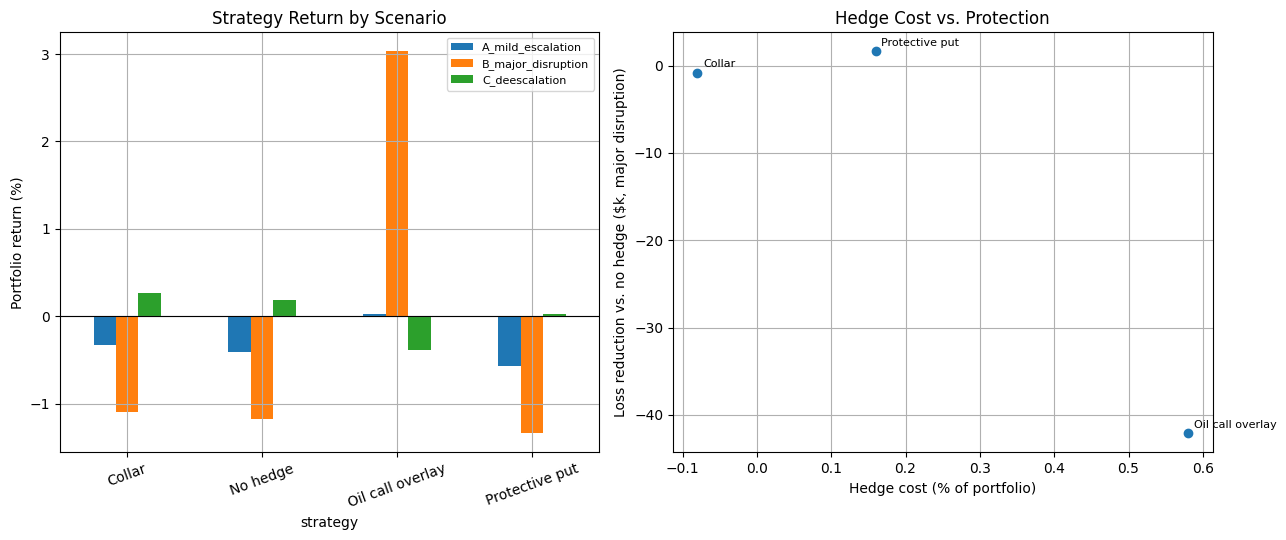

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

pivot = results_df.pivot(index="strategy", columns="scenario", values="return_pct")
pivot = pivot[["A_mild_escalation", "B_major_disruption", "C_deescalation"]]
pivot.plot(kind="bar", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Portfolio return (%)")
axes[0].set_title("Strategy Return by Scenario")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=20)

axes[1].scatter(efficiency_df["cost_pct_of_portfolio"], -efficiency_df["loss_reduction_vs_no_hedge"] / 1000)
for _, row in efficiency_df.iterrows():
    axes[1].annotate(row["strategy"], (row["cost_pct_of_portfolio"], -row["loss_reduction_vs_no_hedge"] / 1000),
                      fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_xlabel("Hedge cost (% of portfolio)")
axes[1].set_ylabel("Loss reduction vs. no hedge ($k, major disruption)")
axes[1].set_title("Hedge Cost vs. Protection")

plt.tight_layout()
plt.savefig("hedge_comparison.png", dpi=130)
plt.show()


## 11. Summary

- Built a $1,000,000 hypothetical client portfolio using the seven project assets (QQQ folded
  into SPY, documented explicitly rather than silently dropped).
- Calibrated two of three scenarios directly from **real, measured** Phase 5 event returns
  (major disruption = E1's actual moves; de-escalation = E3's actual moves); the mild-escalation
  scenario is explicitly labeled as an interpolation, since no real event in the sample was mild.
- Priced a protective SPY put, a SPY collar, and a USO call overlay using the Phase 1
  Black-Scholes-Merton engine, with strikes and volatility drawn from real, current spot and
  VIX/OVX levels.
- Compared all three hedges plus the no-hedge baseline across all three scenarios on cost,
  P&L, and protection efficiency (loss reduction per dollar of premium).
- Reported the Greeks of each hedge position at inception.

**Honest caveats to carry into any write-up or interview:**

1. The hedge horizon (30 calendar days) doesn't exactly match the ~10-trading-day event windows
   the scenario returns were measured over -- a simplification, not a precise match.
2. The oil call overlay isn't hedging an existing position (the portfolio holds no USO); it's an
   *added* directional cross-asset hedge, which is a different thing than the SPY put/collar and
   is described that way rather than blurred together with them.
3. VIX/OVX are volatility proxies, not this project's own measured implied volatility surface --
   same caveat as Phase 4 and Phase 5.

**Next step (Phase 7):** stress-test the Black-Scholes engine itself against these same real
events -- comparing implied vs. actual moves, testing delta-hedging under discrete rebalancing,
and quantifying pricing error around jumps -- in `07_model_risk.ipynb`.
